# Практическое задание №1. Реализация линейной регрессии с градиентным спуском

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload ()

Saving salary_data.csv to salary_data.csv


In [3]:
class LinearRegression():

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.X = None
        self.Y = None

    def fit(self, X, Y):
        self.X = X
        self.Y = Y
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.iterations):
            self.update_weights()
        return self

    def update_weights(self):
        m = len(self.Y)
        Y_pred = self.predict(self.X)
        dw = (-2/m) * np.dot(self.X.T, (self.Y - Y_pred))
        db = (-2/m) * np.sum(self.Y - Y_pred)
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

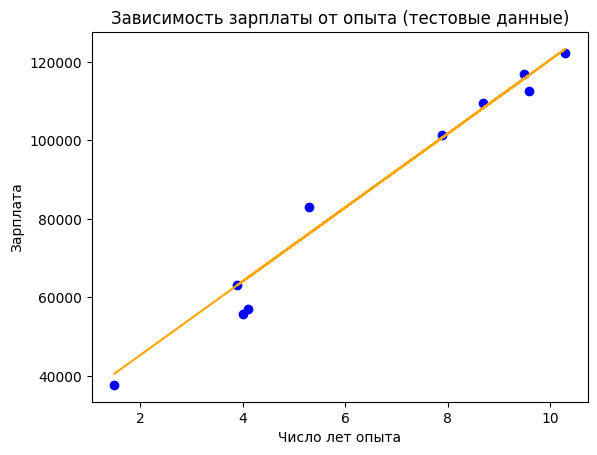

In [4]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 1/3, random_state = 0 )

model = LinearRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

plt.scatter(X_test, Y_test, color = 'blue')
plt.plot(X_test, Y_pred, color = 'orange')
plt.title('Зависимость зарплаты от опыта (тестовые данные)')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')

plt.show()


9501.01
25448.18


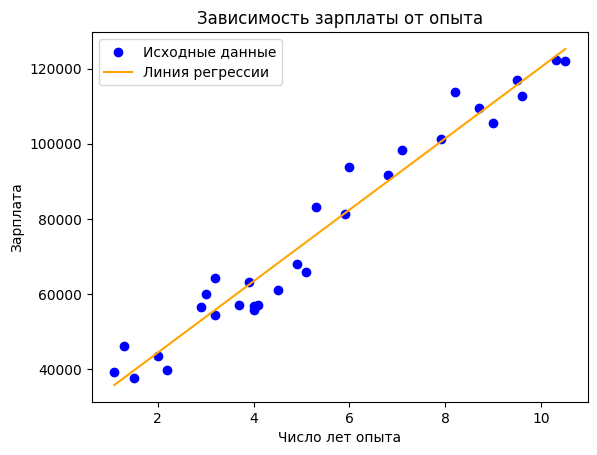

In [5]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

model = LinearRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X, Y)

Y_pred = model.predict(X)

plt.scatter(X, Y, color = 'blue', label='Исходные данные')
plt.plot(X, Y_pred, color = 'orange', label='Линия регрессии')
plt.title('Зависимость зарплаты от опыта')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')
plt.legend()

print(*np.round(model.weights, 2))
print(np.round(model.bias, 2))